# Unit feature scatter plots: waveform shape + firing pattern, with optotagging overlay

Reads the results of notebook 4.2 (optotagging summary) and notebook 4.3
(SortingAnalyzer with `template_metrics`) for one probe/session, and plots
every curated unit in two feature spaces:

1. peak width (half-width) vs. peak-to-valley duration
2. firing rate vs. Prop(ISI > threshold) vs. CV(ISI) (3D)

Units optotagged by the blue laser, red laser, or both are highlighted.
This notebook does not recompute anything from 4.2/4.3 — run those first.

In [1]:
from pathlib import Path
import yaml

# ======== parameters to change ========
session_name    = "IM-1979_2026-09-04"
base_dir_raw    = Path(r"D:/")                # holds <animal>/ephys/<raw session folders> -- needed for bit_volts
base_dir_concat = Path(r"E:/")
tagging_probe   = "probeB"
kilosort_dir    = "kilosort4"                 # KS4 results subfolder name under <processed_session>/<tagging_probe>/
unit_criteria   = {"quality": ["good"]}       # must match what was used in notebook 4.2, so unit_ids line up with opto_df
isi_long_thresh_s = 2.0                        # Prop(ISI > this) threshold
# ======================================

metadata_dir  = Path.cwd().parent
metadata_path = metadata_dir / "metadata" / f"{session_name}.yaml"
with open(metadata_path) as f:
    config = yaml.safe_load(f)

processed_path = base_dir_concat / config["animal"] / "ephys" / config["sessions"]["processed"]
probe_names    = config["streams"]["probes"]

if tagging_probe not in probe_names:
    raise ValueError(f"tagging_probe={tagging_probe!r} not in this session's probes {probe_names}")

print(f"processed_session = {processed_path}")
print(f"tagging_probe     = {tagging_probe}  (available: {probe_names})")

processed_session = E:\D1-1-6_IM-1979\ephys\2026-09-04
tagging_probe     = probeB  (available: ['probeA', 'probeB'])


In [2]:
# ── load curated sorting, optotagging summary, and the template-metrics analyzer ──
import sys
sys.path.append("..")

import pandas as pd
import spikeinterface as si
from src import load_curated_sorting

sorting = load_curated_sorting(processed_path, tagging_probe, kilosort_dir=kilosort_dir,
                               unit_criteria=unit_criteria)
print(f"{tagging_probe}: {len(sorting.unit_ids)} units kept (unit_criteria={unit_criteria})")

summary_path = processed_path / tagging_probe / "optotagging_summary.csv"
if not summary_path.exists():
    raise FileNotFoundError(f"{summary_path} not found -- run notebook 4.2 for this session first")
opto_df = pd.read_csv(summary_path)

analyzer_path = processed_path / tagging_probe / "nwb_export_concat" / "analyzer.zarr"
if not analyzer_path.exists():
    raise FileNotFoundError(f"{analyzer_path} not found -- run notebook 4.3 for this session first")
analyzer = si.load_sorting_analyzer(analyzer_path)

missing_from_analyzer = set(sorting.unit_ids) - set(analyzer.unit_ids)
if missing_from_analyzer:
    print(f"WARNING: {len(missing_from_analyzer)} curated units are not in the analyzer "
          f"(analyzer may have been built with a different unit_criteria snapshot): "
          f"{sorted(missing_from_analyzer)[:10]}{'...' if len(missing_from_analyzer) > 10 else ''}")

probeB: 406 units kept (unit_criteria={'quality': ['good']})


In [3]:
# ── build a one-row-per-unit feature table: waveform metrics + firing-pattern metrics ──
import numpy as np

# waveform metrics from the analyzer's template_metrics extension (units: seconds)
# NOTE: SpikeInterface 0.104 renamed "peak_to_valley" -> "peak_to_trough_duration", and
# split the old single "half_width" into "trough_half_width" / "peak_half_width"
# (spikeinterface.metrics.template.metrics: extracellular waveforms are trough-dominated,
# so "trough_half_width" is the classic spike-width feature used for unit classification).
tm = analyzer.get_extension("template_metrics").get_data()

# firing-pattern metrics computed directly from spike trains -- no existing src helper for this
fs = sorting.get_sampling_frequency()
rows = []
for unit_id in sorting.unit_ids:
    st = sorting.get_unit_spike_train(unit_id) / fs   # seconds
    isi = np.diff(st)
    duration_s = (st[-1] - st[0]) if len(st) > 1 else np.nan
    rows.append({
        "unit_id": unit_id,
        "firing_rate_hz": len(st) / duration_s if duration_s else np.nan,
        "cv_isi": isi.std() / isi.mean() if len(isi) > 1 else np.nan,
        "prop_isi_long": (isi > isi_long_thresh_s).mean() if len(isi) else np.nan,
    })
firing_df = pd.DataFrame(rows).set_index("unit_id")

features_df = firing_df.join(tm[["trough_half_width", "peak_to_trough_duration"]], how="left")
features_df = features_df.loc[[u for u in sorting.unit_ids if u in features_df.index]]

n_nan_waveform = features_df["peak_to_trough_duration"].isna().sum()
if n_nan_waveform:
    print(f"NOTE: {n_nan_waveform} units have no waveform metrics (not present in the analyzer)")

print(f"{len(features_df)} units in features_df")
features_df.describe()

406 units in features_df


,firing_rate_hz,cv_isi,prop_isi_long,trough_half_width,peak_to_trough_duration
count,406.000000,406.000000,406.000000,406.000000,406.000000
mean,1.696569,3.722863,0.189904,0.000235,0.000793
std,3.944829,3.358871,0.158261,0.000081,0.000244
min,0.004202,0.745850,0.000000,0.000027,0.000060
25%,0.102181,2.053274,0.069757,0.000197,0.000727
50%,0.435967,3.105612,0.152710,0.000230,0.000800
75%,1.505072,4.389698,0.271234,0.000270,0.000866
max,30.074598,53.766221,1.000000,0.000953,0.002277


In [4]:
# ── per-unit optotagging color label: blue / red / both / none ──────────────
# color_tagged is True per (unit_id, color) if that unit is tagged at >= 1 power
# level of that color -- a unit can be True for both colors independently.
tagged_blue = set(opto_df.loc[(opto_df["color"] == "blue_laser") & opto_df["color_tagged"], "unit_id"])
tagged_red  = set(opto_df.loc[(opto_df["color"] == "red_laser")  & opto_df["color_tagged"], "unit_id"])

def tag_label(unit_id):
    in_blue, in_red = unit_id in tagged_blue, unit_id in tagged_red
    if in_blue and in_red:
        return "both"
    if in_blue:
        return "blue"
    if in_red:
        return "red"
    return "none"

features_df["tag"] = [tag_label(u) for u in features_df.index]

TAG_COLORS = {"none": "0.75", "blue": "tab:blue", "red": "tab:red", "both": "tab:purple"}
TAG_ORDER  = ["none", "blue", "red", "both"]   # plot 'none' first so it sits behind the tagged points

print(features_df["tag"].value_counts().reindex(TAG_ORDER, fill_value=0))

tag
none    322
blue     84
red       0
both      0
Name: count, dtype: int64


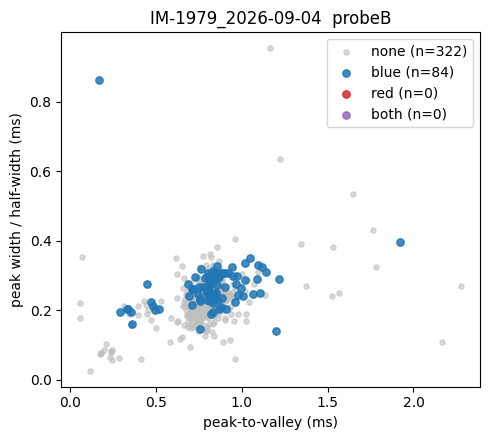

In [5]:
# ── Figure 1: peak width vs peak-to-valley ───────────────────────────────────
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4.5))
for tag in TAG_ORDER:
    d = features_df[features_df["tag"] == tag]
    ax.scatter(d["peak_to_trough_duration"] * 1000, d["trough_half_width"] * 1000,   # seconds -> ms
               s=28 if tag != "none" else 14, c=TAG_COLORS[tag], label=f"{tag} (n={len(d)})",
               alpha=0.85 if tag != "none" else 0.6)
ax.set_xlabel("peak-to-valley (ms)")
ax.set_ylabel("peak width / half-width (ms)")
ax.set_title(f"{session_name}  {tagging_probe}")
ax.legend()
fig.tight_layout()

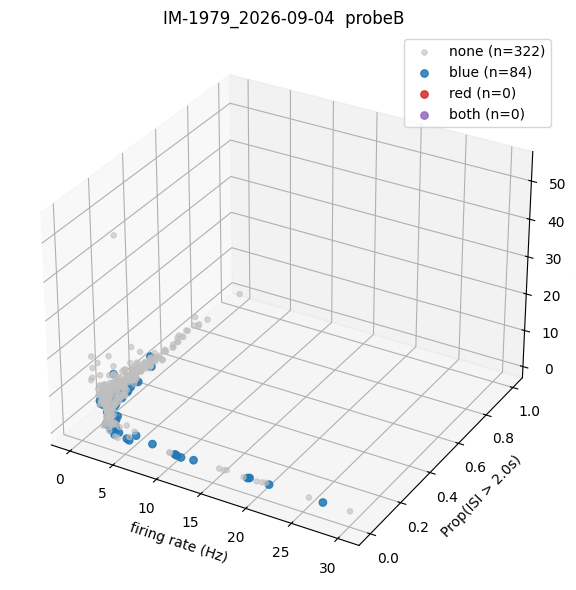

In [6]:
# ── Figure 2: firing rate / Prop(ISI > threshold) / CV(ISI) (3D) ────────────
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 -- registers the '3d' projection

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")
for tag in TAG_ORDER:
    d = features_df[features_df["tag"] == tag]
    ax.scatter(d["firing_rate_hz"], d["prop_isi_long"], d["cv_isi"],
               s=28 if tag != "none" else 14, c=TAG_COLORS[tag], label=f"{tag} (n={len(d)})",
               alpha=0.85 if tag != "none" else 0.6)
ax.set_xlabel("firing rate (Hz)")
ax.set_ylabel(f"Prop(ISI > {isi_long_thresh_s}s)")
ax.set_zlabel("CV(ISI)")
ax.set_title(f"{session_name}  {tagging_probe}")
ax.legend()
fig.tight_layout()

In [7]:
# ── TEMP: list tagged unit ids to look up in Phy ─────────────────────────────
# unit_id here == Phy's original cluster_id for this sorting (no renumbering).
for tag in ["blue", "red", "both"]:
    ids = sorted(features_df.index[features_df["tag"] == tag].tolist())
    print(f"{tag} (n={len(ids)}): {ids}")

blue (n=84): [32, 133, 208, 209, 210, 212, 219, 228, 243, 247, 266, 268, 271, 300, 360, 392, 398, 399, 403, 406, 427, 436, 440, 443, 448, 463, 471, 478, 495, 501, 502, 511, 521, 523, 527, 528, 529, 535, 543, 545, 549, 552, 556, 559, 561, 568, 573, 576, 578, 581, 583, 587, 590, 606, 607, 608, 619, 620, 621, 622, 623, 624, 625, 626, 631, 640, 641, 644, 649, 660, 662, 669, 670, 675, 685, 688, 691, 696, 700, 705, 777, 809, 837, 870]
red (n=0): []
both (n=0): []


In [ ]:
# ── split units into tagged / untagged and compare their features ───────────
tagged_units_df   = features_df[features_df["tag"] != "none"]
untagged_units_df = features_df[features_df["tag"] == "none"]

print(f"tagged:   {len(tagged_units_df)} units")
print(f"untagged: {len(untagged_units_df)} units")

feature_cols = ["trough_half_width", "peak_to_trough_duration", "firing_rate_hz", "cv_isi", "prop_isi_long"]
display(features_df.groupby(features_df["tag"] != "none")[feature_cols].describe().T)

tagged:   84 units
untagged: 322 units


tag                                 False      True 
trough_half_width       count  322.000000  84.000000
                        mean     0.000227   0.000267
                        std      0.000079   0.000081
                        min      0.000027   0.000140
                        25%      0.000190   0.000229
                        50%      0.000223   0.000260
                        75%      0.000260   0.000297
                        max      0.000953   0.000863
peak_to_trough_duration count  322.000000  84.000000
                        mean     0.000785   0.000824
                        std      0.000245   0.000237
                        min      0.000060   0.000170
                        25%      0.000718   0.000757
                        50%      0.000792   0.000830
                        75%      0.000857   0.000913
                        max      0.002277   0.001920
firing_rate_hz          count  322.000000  84.000000
                        mean     1.342145   3.055191
                        std      3.556617   4.965523
                        min      0.004202   0.022613
                        25%      0.076565   0.624813
                        50%      0.288444   1.330321
                        75%      1.147518   3.102563
                        max     30.074598  27.158143
cv_isi                  count  322.000000  84.000000
                        mean     4.041396   2.501816
                        std      3.653021   1.240378
                        min      0.745850   0.976062
                        25%      2.310859   1.581988
                        50%      3.392047   2.087840
                        75%      4.633870   3.063348
                        max     53.766221   7.722256
prop_isi_long           count  322.000000  84.000000
                        mean     0.210007   0.112844
                        std      0.164874   0.097496
                        min      0.000000   0.000000
                        25%      0.081171   0.033689
                        50%      0.183497   0.088123
                        75%      0.293233   0.155918
                        max      1.000000   0.419192

In [9]:
# ── filter by an arbitrary feature threshold, split tagged vs untagged ───────
firing_rate_thresh = 10.0   # Hz -- change this to filter on a different value

high_fr = features_df[features_df["firing_rate_hz"] > firing_rate_thresh]
high_fr_tagged   = high_fr[high_fr["tag"] != "none"].sort_values("firing_rate_hz", ascending=False)
high_fr_untagged = high_fr[high_fr["tag"] == "none"].sort_values("firing_rate_hz", ascending=False)

print(f"firing_rate_hz > {firing_rate_thresh}: {len(high_fr)} units")
print(f"  tagged   (n={len(high_fr_tagged)}): "
      + ", ".join(f"{uid}={fr:.1f}Hz" for uid, fr in high_fr_tagged["firing_rate_hz"].items()))
print(f"  untagged (n={len(high_fr_untagged)}): "
      + ", ".join(f"{uid}={fr:.1f}Hz" for uid, fr in high_fr_untagged["firing_rate_hz"].items()))

firing_rate_hz > 10.0: 19 units
  tagged   (n=8): 209=27.2Hz, 398=21.3Hz, 511=19.1Hz, 619=18.9Hz, 360=12.9Hz, 631=11.5Hz, 608=11.0Hz, 576=10.8Hz
  untagged (n=11): 129=30.1Hz, 120=25.6Hz, 265=20.9Hz, 33=20.5Hz, 680=19.9Hz, 142=18.5Hz, 311=16.6Hz, 663=16.3Hz, 197=15.8Hz, 701=10.2Hz, 95=10.1Hz


## Per-unit diagnostic plot

For one unit at a time: mean waveform split by baseline / blue-laser / red-laser
trials, its position on the probe, and where it sits in the peak-to-valley vs
half-width population (this unit highlighted, everything else gray). This
complements notebook 4.2's `plot_opto_response` (raster/PSTH) rather than
replacing it.

The `analyzer`'s `waveforms`/`templates` extensions are only computed over a
fixed random subsample of spikes (`random_spikes`, 500/unit, drawn uniformly
across the whole recording) — they cannot be split by laser condition. So the
cells below re-extract raw single-channel snippets directly from
`continuous.dat`, reproducing the same CAR + high-pass preprocessing as
notebook 4.3's `build_concat_recording` (duplicated here on purpose rather than
shared via `src/` — keep the two in sync by hand if those filter parameters
ever change).

In [10]:
# ── load laser events + rebuild the preprocessed (CAR + high-pass) recording ────
import spikeinterface.full as si_full
from spikeinterface.core.template_tools import get_template_extremum_channel
from src import load_laser_events, load_laser_protocol, annotate_laser_events_with_protocol
from src import oe_parse_folders, oe_parse_params
from src.optotagging import DEFAULT_OPTOTAG_PARAMS

laser_events = load_laser_events(processed_path, probe_name=tagging_probe, session_id="optotagging")
protocol = load_laser_protocol(processed_path / "laser_control_protocol_dual_mega2560.csv")
laser_events = annotate_laser_events_with_protocol(laser_events, protocol)

# Same response window compute_population_opto_response used to decide tagging in
# 4.2 -- keep the baseline/blue/red split consistent with how tagging itself works.
resp_start_ms, resp_end_ms = DEFAULT_OPTOTAG_PARAMS["response_window_ms"]


def read_phy_params(kilosort_path):
    """params.py is plain python assignments -- exec it the way Phy itself does."""
    namespace = {}
    exec((kilosort_path / "params.py").read_text(), {}, namespace)
    return namespace


kilosort_path = processed_path / tagging_probe / kilosort_dir
concat_dat    = processed_path / tagging_probe / "continuous.dat"
ks_params     = read_phy_params(kilosort_path)
channel_map       = np.load(kilosort_path / "channel_map.npy").ravel()
channel_positions = np.load(kilosort_path / "channel_positions.npy")

# bit_volts is a per-probe value read from the raw session's settings.xml/oebin, not a
# fixed hardware constant -- any raw session for this probe carries the same value.
raw_session_dir = base_dir_raw / config["animal"] / "ephys" / config["sessions"]["optotagging"]
_, raw_oe_paths = oe_parse_folders(raw_session_dir)
raw_probe_params, _ = oe_parse_params(raw_oe_paths["xml"], raw_oe_paths["oebin"])
bit_volts = float(next(p for p in raw_probe_params
                       if str(p["stream_name"]).split(".")[-1].lower() == tagging_probe.lower())
                  ["channel_bit_volts"])

recording = si_full.read_binary(
    concat_dat, sampling_frequency=float(ks_params["sample_rate"]),
    num_channels=int(ks_params["n_channels_dat"]), dtype=ks_params["dtype"],
    gain_to_uV=bit_volts, offset_to_uV=0.0)
if len(channel_map) != recording.get_num_channels():
    recording = recording.select_channels([recording.channel_ids[int(i)] for i in channel_map])
# Kilosort 4 defaults, reproduced here so waveform troughs line up across spikes --
# see notebook 4.3's build_concat_recording docstring for the full justification.
recording = si_full.common_reference(recording, reference="global", operator="median")
recording = si_full.highpass_filter(recording, freq_min=300.0)

print(f"recording: {recording.get_num_channels()} channels @ {recording.get_sampling_frequency()} Hz, "
      f"{recording.get_num_samples()} samples")
print(f"laser_events: {len(laser_events)} pulses, colors={sorted(laser_events['color'].unique())}")

recording: 376 channels @ 30000.0 Hz, 267144415 samples
laser_events: 800 pulses, colors=['blue_laser', 'red_laser']


In [11]:
# ── spike classification + single-channel waveform extraction helpers ──────────
def classify_spikes_by_laser(spike_samples_concat, laser_events, fs,
                             resp_start_ms=resp_start_ms, resp_end_ms=resp_end_ms):
    """dict: color -> bool mask over spike_samples_concat (spike falls in the
    response window after >=1 pulse of that color), plus 'baseline' = not in
    any color's window."""
    spike_s = spike_samples_concat / fs
    masks = {}
    any_evoked = np.zeros(len(spike_s), dtype=bool)
    for color in laser_events["color"].unique():
        pulses_s = laser_events.loc[laser_events["color"] == color, "on_sample_concat"].to_numpy() / fs
        in_window = np.zeros(len(spike_s), dtype=bool)
        for t0 in pulses_s:
            in_window |= (spike_s >= t0 + resp_start_ms / 1000) & (spike_s <= t0 + resp_end_ms / 1000)
        masks[color] = in_window
        any_evoked |= in_window
    masks["baseline"] = ~any_evoked
    return masks


def extract_mean_waveform(recording, spike_samples, channel_id, ms_before, ms_after, fs,
                          max_spikes=500, seed=0):
    """Random-subsample up to max_spikes, pull raw single-channel snippets from
    the recording, and average them. max_spikes=500 matches notebook 4.3's
    random_spikes extension default, to keep this fast for high-firing-rate
    (esp. baseline) conditions with thousands of spikes."""
    rng = np.random.default_rng(seed)
    if len(spike_samples) > max_spikes:
        spike_samples = rng.choice(spike_samples, size=max_spikes, replace=False)
    n_before = int(round(ms_before / 1000 * fs))
    n_after  = int(round(ms_after / 1000 * fs))
    snippets = []
    for s in spike_samples:
        start, end = int(s) - n_before, int(s) + n_after
        if start < 0 or end > recording.get_num_samples():
            continue
        snippets.append(recording.get_traces(start_frame=start, end_frame=end,
                                             channel_ids=[channel_id])[:, 0])
    if not snippets:
        return None, 0
    return np.mean(snippets, axis=0), len(snippets)

In [15]:
# ── plot_unit_diagnostic: waveform-by-condition + probe position + p2v/half-width ──
#   diagnostic_figures_mode == "plot" : plot n_plot_preview random tagged units inline
#   diagnostic_figures_mode == "save" : save every tagged unit to disk, format set by figure_format
#       figure_format == "pdf" : all units -> one multi-page unit_diagnostic_figures.pdf
#       figure_format == "svg" / "png" : one file per unit, in unit_diagnostic_figures_<format>/
#                                         (png saved with a transparent background, 300 dpi)
import random
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages


def plot_unit_diagnostic(unit_id, ms_before=1.5, ms_after=2.5):
    fs = sorting.get_sampling_frequency()
    peak_ch = get_template_extremum_channel(analyzer, peak_sign="neg", outputs="id")[unit_id]
    spike_samples = sorting.get_unit_spike_train(unit_id)
    masks = classify_spikes_by_laser(spike_samples, laser_events, fs)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # panel A: mean waveform by condition on the unit's peak channel
    wf_colors = {"baseline": "0.3", "blue_laser": "tab:blue", "red_laser": "tab:red"}
    for cond, color in wf_colors.items():
        mask = masks.get(cond)
        if mask is None or mask.sum() == 0:
            continue
        wf, n = extract_mean_waveform(recording, spike_samples[mask], peak_ch, ms_before, ms_after, fs)
        if wf is None:
            continue
        n_before = int(round(ms_before / 1000 * fs))
        t_ms = (np.arange(len(wf)) - n_before) / fs * 1000
        axes[0].plot(t_ms, wf, color=color, label=f"{cond} (n={n})")
    axes[0].axvline(0, color="0.85", lw=0.8, zorder=0)
    axes[0].set_xlabel("time (ms)")
    axes[0].set_ylabel("amplitude (uV)")
    axes[0].set_title(f"waveform (peak ch {peak_ch})")
    axes[0].legend(fontsize=8)

    # panel B: probe position, this unit's peak channel highlighted
    axes[1].scatter(channel_positions[:, 0], channel_positions[:, 1], s=8, c="0.8")
    ch_idx = list(recording.channel_ids).index(peak_ch)
    highlight_color = TAG_COLORS.get(features_df.loc[unit_id, "tag"], "k")
    axes[1].scatter(*channel_positions[ch_idx], s=80, c=highlight_color, edgecolor="k", linewidth=0.5)
    axes[1].set_xlabel("x (um)")
    axes[1].set_ylabel("y (um)")
    axes[1].set_title("probe position")
    axes[1].set_aspect("equal")

    # panel C: peak-to-valley vs half-width, only this unit colored
    axes[2].scatter(features_df["peak_to_trough_duration"] * 1000,
                    features_df["trough_half_width"] * 1000, s=10, c="0.8")
    row = features_df.loc[unit_id]
    axes[2].scatter(row["peak_to_trough_duration"] * 1000, row["trough_half_width"] * 1000,
                    s=90, c=highlight_color, edgecolor="k", linewidth=0.5)
    axes[2].set_xlabel("peak-to-valley (ms)")
    axes[2].set_ylabel("peak width / half-width (ms)")
    axes[2].set_title("waveform-shape population")

    fig.suptitle(f"unit {unit_id}  (tag={row['tag']}, firing_rate={row['firing_rate_hz']:.2f} Hz)")
    fig.tight_layout()
    return fig


# ======== parameters to change ========
diagnostic_figures_mode = "save"   # "plot" or "save"
figure_format = "svg"              # "pdf", "svg", or "png" -- only used when mode == "save"
n_plot_preview = 4                 # number of random tagged units to preview when mode == "plot"
# ======================================

tagged_unit_ids = sorted(tagged_units_df.index.tolist())
print(f"{len(tagged_unit_ids)} tagged units")

if diagnostic_figures_mode == "plot":
    for unit_id in random.sample(tagged_unit_ids, k=min(n_plot_preview, len(tagged_unit_ids))):
        plot_unit_diagnostic(unit_id)

elif diagnostic_figures_mode == "save":
    if figure_format == "pdf":
        pdf_path = processed_path / tagging_probe / "unit_diagnostic_figures.pdf"
        with PdfPages(pdf_path) as pdf:
            for unit_id in tagged_unit_ids:
                fig = plot_unit_diagnostic(unit_id)
                pdf.savefig(fig, bbox_inches="tight")
                plt.close(fig)
        print(f"saved {len(tagged_unit_ids)} pages to {pdf_path}")

    elif figure_format in ("svg", "png"):
        out_dir = processed_path / tagging_probe / f"unit_diagnostic_figures_{figure_format}"
        out_dir.mkdir(exist_ok=True)
        for unit_id in tagged_unit_ids:
            fig = plot_unit_diagnostic(unit_id)
            fig_path = out_dir / f"unit_{unit_id}.{figure_format}"
            if figure_format == "png":
                fig.savefig(fig_path, bbox_inches="tight", transparent=True, dpi=300)
            else:
                fig.savefig(fig_path, bbox_inches="tight", transparent=True)
            plt.close(fig)
        print(f"saved {len(tagged_unit_ids)} files to {out_dir}")

    else:
        raise ValueError(f"figure_format must be 'pdf', 'svg', or 'png', got {figure_format!r}")

else:
    raise ValueError(f"diagnostic_figures_mode must be 'plot' or 'save', got {diagnostic_figures_mode!r}")

84 tagged units
saved 84 files to E:\D1-1-6_IM-1979\ephys\2026-09-04\probeB\unit_diagnostic_figures_svg
